In [115]:
import os

# Set this to "1" to disable torch.compile globally
# os.environ["TORCH_COMPILE_DISABLE"] = "1"
import torch
import torch.nn as nn

import numpy as np
from typing import NamedTuple
import matplotlib.pyplot as plt
# from scipy.stats import gamma, poisson

from models.utils import build_warmup_epochs
from models.inn import RealNVP, RealNVPSummary
from models.regressionNetwork import RegressionNetwork, train_regression_network

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.set_float32_matmul_precision("high")
from tqdm import tqdm
import torch.nn.utils as utils

In [116]:
dataset = np.load("dataset.npz")

seed = 67
print(dataset)
foot = dataset["foot"]

com_trace = dataset["com"]
com = com_trace[:, com_trace.shape[1] // 2]  # get middle position

print(f"{foot.shape=}")
print(f"{com.shape=}")
print(f"{com_trace.shape=}")
# flatten foot
foot_reshape = foot.reshape((foot.shape[0], -1))  # flatten(1)?

NpzFile 'dataset.npz' with keys: foot, com, height
foot.shape=(100000, 39, 6)
com.shape=(100000, 3)
com_trace.shape=(100000, 39, 3)


0


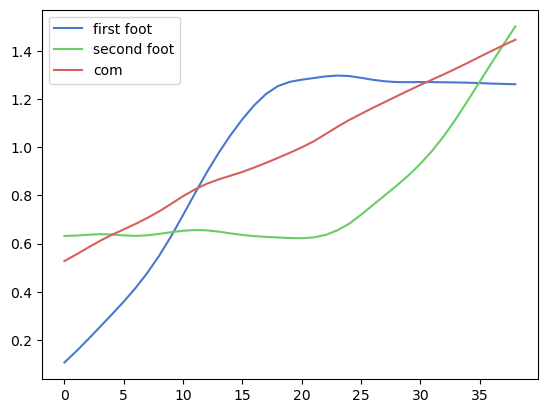

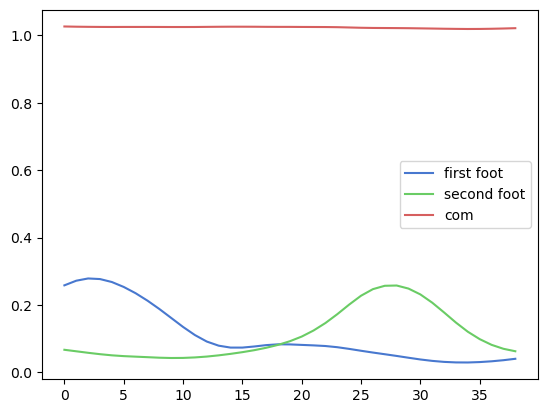

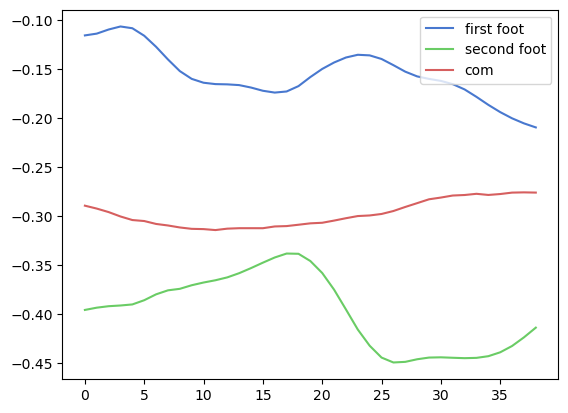

In [117]:
i_th_example = np.random.randint(0, foot.shape[1], (1,)).item()
i_th_example = 0
max_frame = 15
max_frame = foot.shape[1]
print(i_th_example)
plt.plot(foot[i_th_example, :max_frame, 0])
plt.plot(foot[i_th_example, :max_frame, 3])
plt.plot(com_trace[i_th_example, :max_frame, 0])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(foot[i_th_example, :max_frame, 1])
plt.plot(foot[i_th_example, :max_frame, 4])
plt.plot(com_trace[i_th_example, :max_frame, 1])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(foot[i_th_example, :max_frame, 2])
plt.plot(foot[i_th_example, :max_frame, 5])
plt.plot(com_trace[i_th_example, :max_frame, 2])
plt.legend(["first foot", "second foot", "com"])
plt.show()

In [118]:
print(i_th_example)

0


In [119]:
if False:
    test = foot
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 0], bins=25)
        plt.show()
    print("-" * 89)
    print("now the other foot:")
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 4], bins=25)
        plt.show()

In [163]:
DATASET_PATH = "dataset.npz"

SAMPLE_RATE = 50
WINDOW_SEC = 0.3
WINDOW_FRAMES = int(SAMPLE_RATE * WINDOW_SEC)


def make_windows(foot, com, W):
    """
    Converts raw foot and COM trajectories into sliding window samples.

    For each window starting at frame t:
      - foot positions are expressed relative to foot[t]
      - COM is expressed relative to the midpoint of both feet at t
      - per-sequence mean is removed to eliminate systematic bias
        between synthetic training data and real validation data

    Args:
        foot: (T, 6) array of foot positions in metres
        com:  (T, 3) array of COM positions in metres
        W:    window length in frames

    Returns:
        X: (T-W+1, W*6) input vectors
        y: (T-W+1, 3)   COM targets
    """
    frames_per_simulation = foot.shape[0]
    windows_per_simulation = frames_per_simulation - W + 1

    com_infer_frame = W // 2
    # this is time moment the com will be give to the model as ground truth
    # it is also the frame the feet will be middled
    # windows_per_simulation // 2 equls the middle of each ovservation the model sees.
    # 0 wold be the begin of the movement

    foot_windows = np.lib.stride_tricks.sliding_window_view(foot, (W, 6))[:, 0]
    first_feet_mid_window_frame = (
        foot_windows[:, com_infer_frame, :3]
    )
    average_feet_first_frame_both_feet = np.concat(
        [first_feet_mid_window_frame, first_feet_mid_window_frame], 1
    )
    foot_windows_start_at_0 = (
        foot_windows - average_feet_first_frame_both_feet[:, np.newaxis, :]
    )
    com_rel = (
        com[com_infer_frame : com_infer_frame + windows_per_simulation]
        - first_feet_mid_window_frame
    )

    # TODO: change to middle of trace
    X = foot_windows_start_at_0.astype(np.float32)  # .reshape(n, -1).astype(np.float32)
    y = com_rel.astype(np.float32)
    return X, y


X, Y = make_windows(foot[0], com_trace[0], 15)


def compute_stats(path):
    """
    Estimates normalisation statistics from the dataset without loading
    everything into memory. Uses memory-mapped file access and samples
    500 simulations to compute mean and std of the windowed data.
    """
    print(f"\n{'─'*60}")
    print(f"  Step 1/3 - computing normalisation stats")
    print(f"{'─'*60}")
    print(f"  Dataset       : {path}")
    print(f"  Window        : {WINDOW_FRAMES} frames = {WINDOW_SEC*1000:.0f} ms")

    npz = np.load(path, mmap_mode="r")
    foot = npz["foot"]
    com = npz["com"]
    n_simulations, n_frames_per_sim, _ = foot.shape
    print(f"  Simulations   : {n_simulations:,}   frames/sim : {n_frames_per_sim}")

    rng = np.random.default_rng(0)
    idx = rng.choice(n_simulations, size=min(5000, n_simulations), replace=False)
    W = WINDOW_FRAMES

    foot_windows, com_windows = [], []
    for si in idx:
        X_i, y_i = make_windows(
            foot[si].astype(np.float32), com[si].astype(np.float32), W
        )
        foot_windows.append(X_i)
        com_windows.append(y_i)

    foot_all = np.concatenate(foot_windows)
    com_all = np.concatenate(com_windows)

    foot_mean = (
        foot_all.reshape((foot_all.shape[0], foot_all.shape[1], 2, 3))
        .mean((0, 1, 2))
        .astype(np.float32)
    )
    foot_mean = np.concat([foot_mean, foot_mean]).reshape(
        (1, 1, 6)
    )  # use the same for both feet
    # foot_mean = foot_all.mean(0).astype(np.float32)
    foot_std = (
        foot_all.reshape((foot_all.shape[0], foot_all.shape[1], 2, 3))
        .std((0, 1, 2))
        .astype(np.float32)
    )
    foot_std = np.concat([foot_std, foot_std]).reshape((1, 1, 6))
    # foot_std = foot_all.std(0).astype(np.float32)  + 1e-8

    com_mean = com_all.mean(0).astype(np.float32)
    com_std = com_all.std(0).astype(np.float32) + 1e-8

    print(f"  COM std       : {(com_std*100).round(1)} cm")

    return dict(
        foot_mean=foot_mean,
        foot_std=foot_std,
        com_mean=com_mean,
        com_std=com_std,
        S=n_simulations,
        T=n_frames_per_sim,
        W=W,
    )


def _sims_to_tensors(npz_foot, npz_com, indices, stats):
    """Loads simulations, builds windows and normalises."""
    W = stats["W"]
    foot_mean = np.array(stats["foot_mean"], dtype=np.float32)
    foot_std = np.array(stats["foot_std"], dtype=np.float32)
    com_mean = np.array(stats["com_mean"], dtype=np.float32)
    com_std = np.array(stats["com_std"], dtype=np.float32)

    #TODO: check if better that both feet have independant mean and std

    Xs, ys = [], []
    for i in range(len(indices)):
        X_i, y_i = make_windows(
            npz_foot[indices[i]].astype(np.float32),
            npz_com[indices[i]].astype(np.float32),
            W,
        )
        Xs.append((X_i - foot_mean) / foot_std)
        ys.append((y_i - com_mean) / com_std)

        # Xs.append(X_i )
        # ys.append(y_i)

    return torch.from_numpy(np.concatenate(Xs)), torch.from_numpy(np.concatenate(ys))


stats = compute_stats(DATASET_PATH)

npz = np.load(DATASET_PATH, mmap_mode="r")
npz_foot = npz["foot"]
npz_com = npz["com"]

S = stats["S"]
W = stats["W"]
input_dim = W * 6

rng = np.random.default_rng(99)
all_idx    = rng.permutation(S)
# all_idx = np.arange(S)
split_point = int(S * 0.8)

train_pool = all_idx[:split_point]
val_idx = all_idx[split_point:]

train_Xv, train_yv = _sims_to_tensors(npz_foot, npz_com, train_pool, stats)
test_foot, test_com = _sims_to_tensors(npz_foot, npz_com, val_idx, stats)


────────────────────────────────────────────────────────────
  Step 1/3 - computing normalisation stats
────────────────────────────────────────────────────────────
  Dataset       : dataset.npz
  Window        : 15 frames = 300 ms
  Simulations   : 100,000   frames/sim : 39
  COM std       : [25.9  8.2  5.6] cm


In [121]:
print(train_Xv.shape, train_yv.shape)
print(test_foot.shape, test_com.shape)

torch.Size([2000000, 15, 6]) torch.Size([2000000, 3])
torch.Size([500000, 15, 6]) torch.Size([500000, 3])


In [122]:
print(f"{W=}")
print(X.shape, Y.shape)
print(train_Xv.shape, train_yv.shape, S * 0.8 * 25)

W=15
(25, 15, 6) (25, 3)
torch.Size([2000000, 15, 6]) torch.Size([2000000, 3]) 2000000.0


(array([  1640.,  92060., 318411., 233901., 252685., 405969., 370465.,
        283180.,  41190.,    499.]),
 array([-2.76290298, -2.21798134, -1.67305994, -1.12813842, -0.58321691,
        -0.03829551,  0.50662613,  1.05154777,  1.59646916,  2.14139056,
         2.68631172]),
 <BarContainer object of 10 artists>)

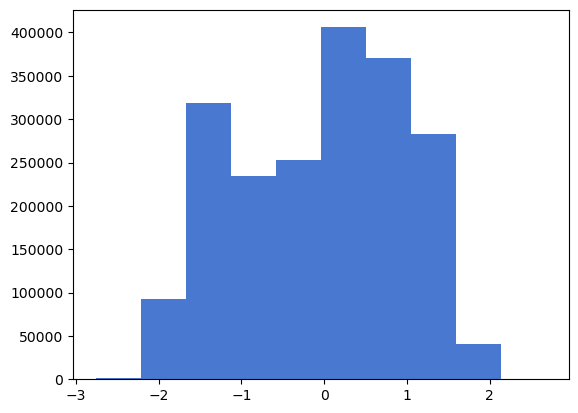

In [123]:
plt.hist(train_yv[:,0])

#WARNING: these plots are not corrected for mean and std shifts.
0


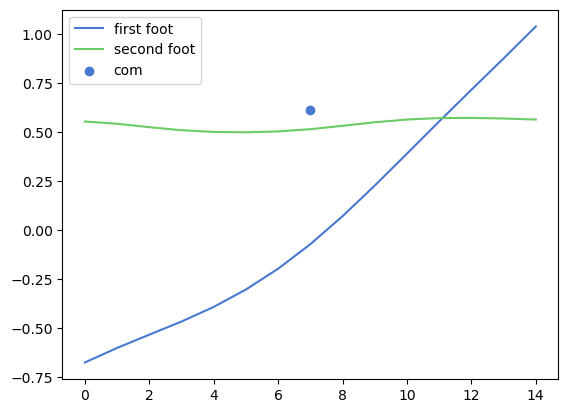

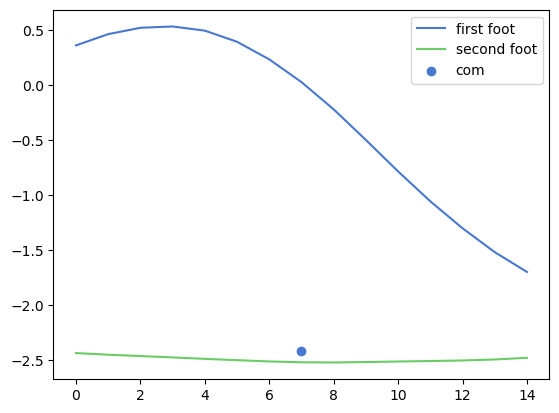

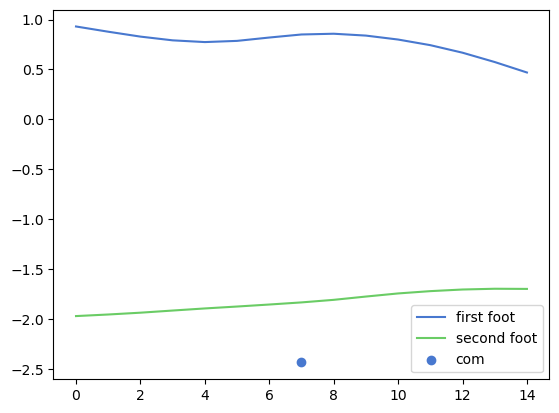

In [124]:
#WARNING: these plots are not corrected for mean and std shifts.
print("#WARNING: these plots are not corrected for mean and std shifts.")
i_th_example = np.random.randint(0, foot.shape[1], (1,)).item()
i_th_example = 0
test = train_Xv.reshape((train_Xv.shape[0], -1, 6))
print(i_th_example)
plt.plot(test[i_th_example, :, 0])
plt.plot(test[i_th_example, :, 3])
plt.scatter([7], train_yv[i_th_example, 0])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(test[i_th_example, :, 1])
plt.plot(test[i_th_example, :, 4])
plt.scatter([7], train_yv[i_th_example, 1])
plt.legend(["first foot", "second foot", "com"])
plt.show()
plt.plot(test[i_th_example, :, 2])
plt.plot(test[i_th_example, :, 5])
plt.scatter([7], train_yv[i_th_example, 2])
plt.legend(["first foot", "second foot", "com"])
plt.show()

In [125]:
if False:
    test = train_Xv.reshape((train_Xv.shape[0], -1, 6))
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 0], bins=25)
        plt.show()
    print("-" * 89)
    print("now the other foot:")
    for frame in range(test.shape[1]):
        plt.hist(test[:, frame, 4], bins=25)
        plt.show()

In [126]:
for frame in range(com_trace.shape[1]):
    pass
    # plt.hist(com_trace[:,frame,0],bins= 25)
    # plt.show()

In [127]:
for frame in range(foot.shape[1]):
    pass
    # plt.hist(foot[:,frame,0],bins= 25)
    # plt.show()

In [128]:
# create dataloaders:
from torch.utils.data import DataLoader, TensorDataset


train_datatensor = TensorDataset(train_yv, train_Xv.flatten(1))
test_datatensor = TensorDataset(test_com, test_foot.flatten(1))


def create_dataloaders(batch_size, num_workers=11):
    train_loader = DataLoader(
        train_datatensor,
        shuffle=True,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=True,
        drop_last=True,  # otherwise, some instances are weighed higher
    )

    test_loader = DataLoader(
        test_datatensor,
        shuffle=False,  # unnecesarry
        batch_size=batch_size * 16,  # OPT: increase
        num_workers=max(num_workers // 2, 8),
        pin_memory=True,
        persistent_workers=True,
    )
    return train_loader, test_loader

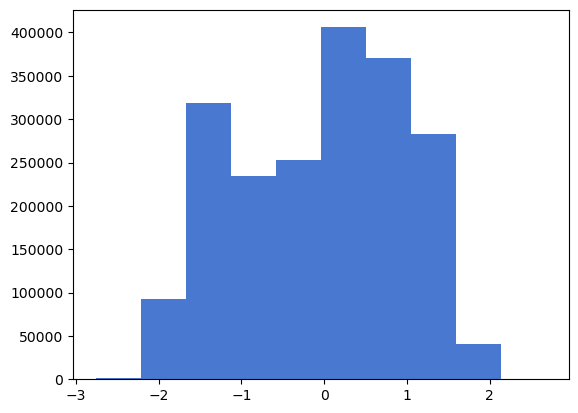

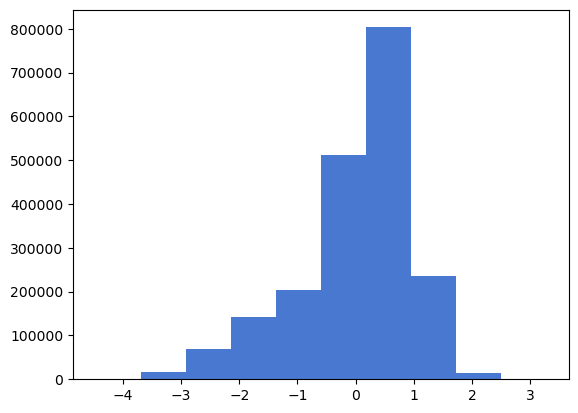

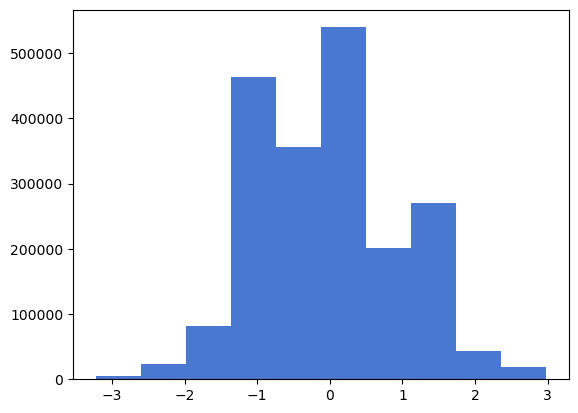

In [129]:
plt.hist(train_yv[:, 0])
plt.show()
plt.hist(train_yv[:, 1])
plt.show()
plt.hist(train_yv[:, 2])
plt.show()

torch.Size([2000000, 15, 6])


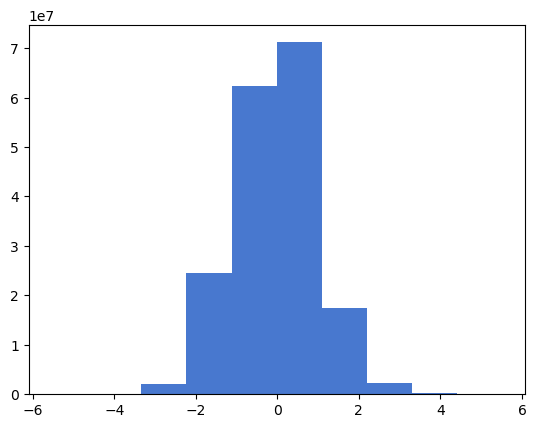

tensor([0.5951, 0.8763, 0.3389, 1.1929, 1.3685, 0.7304, 0.5194, 0.7849, 0.3111,
        1.2227, 1.3523, 0.7147, 0.4403, 0.6805, 0.2791, 1.2492, 1.3313, 0.7002,
        0.3579, 0.5634, 0.2407, 1.2721, 1.3081, 0.6869, 0.2724, 0.4347, 0.1941,
        1.2914, 1.2857, 0.6752, 0.1840, 0.2960, 0.1368, 1.3070, 1.2667, 0.6655,
        0.0931, 0.1501, 0.0710, 1.3193, 1.2530, 0.6585, 0.0000, 0.0000, 0.0000,
        1.3282, 1.2454, 0.6543, 0.0946, 0.1509, 0.0719, 1.3339, 1.2434, 0.6529,
        0.1898, 0.2991, 0.1405, 1.3363, 1.2456, 0.6545, 0.2847, 0.4406, 0.2029,
        1.3353, 1.2504, 0.6587, 0.3783, 0.5718, 0.2573, 1.3308, 1.2560, 0.6646,
        0.4696, 0.6906, 0.3028, 1.3226, 1.2608, 0.6715, 0.5577, 0.7961, 0.3403,
        1.3104, 1.2635, 0.6789, 0.6418, 0.8888, 0.3712, 1.2942, 1.2632, 0.6870])


In [130]:
print(train_Xv.shape)
plt.hist(train_Xv.flatten())
plt.show()
print(train_Xv.flatten(1).std(0))

In [131]:
# print input sizes for model
train_loader = create_dataloaders(32)[0]
com_test, foot_test = next(iter(train_loader))
print(foot_test.shape, com_test.shape)

torch.Size([32, 90]) torch.Size([32, 3])


In [132]:
@torch.compile()
def compute_mmd(x, y, sigma=1.0):
    """
    Computes the Maximum Mean Discrepancy (MMD) between two sets of samples.
    Args:
        x: Tensor of shape [n, d] (Samples from Distribution P)
        y: Tensor of shape [m, d] (Samples from Distribution Q)
        sigma: Bandwidth of the RBF kernel
    """
    # 1. Compute distance matrix (n+m, n+m)
    z = torch.cat([x, y], dim=0)
    # Efficient pairwise distance calculation: ||a-b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
    dist_matrix = torch.cdist(z, z, p=2) ** 2

    # 2. Apply Gaussian Kernel
    kernel_matrix = torch.exp(-dist_matrix / (2 * sigma**2))

    # 3. Extract sub-matrices
    n = x.size(0)
    m = y.size(0)

    k_xx = kernel_matrix[:n, :n]
    k_yy = kernel_matrix[n:, n:]
    k_xy = kernel_matrix[:n, n:]

    # 4. Compute MMD^2 (Unbiased estimator)
    # Subtracting the diagonal (self-distances) for k_xx and k_yy
    mmd2 = (
        (k_xx.sum() - n) / (n * (n - 1))
        + (k_yy.sum() - m) / (m * (m - 1))
        - 2 * k_xy.mean()
    )

    return mmd2


# Example Usage
x = torch.randn((100, 2))  # Mean 0
y = torch.randn((100,2))
loss = compute_mmd(x, y)
print(f"MMD: {loss.item():.4f}")

@torch.compile()
def compute_mmd(x, y, sigmas=(0.1, 0.5, 1.0, 2.0, 5.0)):
    z = torch.cat([x, y], dim=0)
    dist_matrix = torch.cdist(z, z, p=2) ** 2
    n, m = x.size(0), y.size(0)
    mmd2 = 0.0
    for sigma in sigmas:
        K = torch.exp(-dist_matrix / (2 * sigma**2))
        k_xx, k_yy, k_xy = K[:n, :n], K[n:, n:], K[:n, n:]
        mmd2 += (k_xx.sum() - n) / (n*(n-1)) \
              + (k_yy.sum() - m) / (m*(m-1)) \
              - 2 * k_xy.mean()
    return mmd2.detach().item()


MMD: -0.0033


In [133]:
from torch import GradScaler
from models.inn import CouplingBlock
from torch.profiler import profile, record_function, ProfilerActivity
import wandb


@torch.compile()
def calculate_loss(output, sum_block_log_det):
    log_prior = 0.5 * torch.sum(output**2, dim=1)
    log_likelihood = log_prior - sum_block_log_det
    # 3. Mean over the batch, then negative for minimization
    loss = torch.mean(log_likelihood)
    return loss


@torch.compile()
def train_step(model, X, Y, optim, scaler, batch_size):
    return


@torch.no_grad()
def test_epoch(model, test_loader):
    model.eval()
    test_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
    test_epoch_length = len(test_loader)
    for com, foot in test_loader:
        com: torch.Tensor
        foot: torch.Tensor
        torch.compiler.cudagraph_mark_step_begin()
        X, Y = com.to(device), foot.to(device)  # TODO: nonblocking
        output, sum_block_log_det = model.forward(X, Y)
        loss = calculate_loss(output, sum_block_log_det)
        test_epoch_loss += loss.mean()
    mmd2 = compute_mmd(output.detach(),torch.randn_like(output))
    test_avg_epoch_loss = (test_epoch_loss / test_epoch_length).item()
    return test_avg_epoch_loss, mmd2


def train_inn_cond(
    model: RealNVP | RealNVPSummary,
    train_loader: torch.utils.data.DataLoader,
    test_loader: torch.utils.data.DataLoader,
    optim: torch.optim.Optimizer,
    scaler: GradScaler,
    lr_scheduler: torch.optim.lr_scheduler.LRScheduler,
    epochs: int,
    history,
    batch_size,
    init_lr,
    reduced_obs_size,
    s_hidden,
    s_layers,
    r_hidden,
    r_blocks,
    lr_warmup_epochs,
):
    """
    model: A inn
    train_set_fn: a function that returns X,Y
    with:
    X: the hidden parameter that we want a posterior for later.
    Y: the condition (like observations that will be available at inference time)

    # scaler = GradScaler("cuda", enabled=(device.type == 'cuda'))
    """
    history["train_loss"] = history.get("train_loss", [])
    history["test_loss"] = history.get("test_loss", [])
    history["test_mmd"] = history.get("test_mmd", [])
    model.train()
    pbar = tqdm(range(epochs), desc="Training", leave=True)
    print(f"{len(train_loader)=}")
    max_steps_per_epoch = 500
    with wandb.init(
        name="test",
        project="SBI_walking",
        config=dict(
            max_steps_per_epoch=max_steps_per_epoch,
            batch_size=batch_size,
            epochs=epochs,
            init_lr=init_lr,
            reduced_obs_size=reduced_obs_size,
            s_hidden=s_hidden,
            s_layers=s_layers,
            r_hidden=r_hidden,
            r_blocks=r_blocks,
            optimizer=optim.__class__.__name__,
            lr_warmup_epochs=lr_warmup_epochs,
            changed="replaced_arange_with_rng_indices, fixed_middle_of_window_point",
        ),
    ) as run:
        for epoch in pbar:
            train_epoch_loss = torch.zeros((1,), requires_grad=False, device=device)
            train_epoch_length = len(train_loader)
            steps_per_epoch = 0
            for com, foot in train_loader:
                com: torch.Tensor
                foot: torch.Tensor
                torch.compiler.cudagraph_mark_step_begin()
                X = (com + torch.normal(0, 0.05, com.shape)).to(
                    device, non_blocking=True
                )
                Y = (foot + torch.normal(0, 0.05, foot.shape)).to(
                    device, non_blocking=True
                )
                optim.zero_grad()
                # with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                # print(X.shape,Y.shape)
                output, sum_block_log_det = model.forward(X, Y)
                # y is used for condition, x is input (see docstring)
                loss = calculate_loss(output, sum_block_log_det)
                loss.backward()
                # scaler.scale(loss).backward()
                # scaler.unscale_(optim)
                # utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                # scaler.step(optim)
                # scaler.update()
                optim.step()
                train_epoch_loss += loss.mean().detach()
                steps_per_epoch += 1
                if steps_per_epoch >= max_steps_per_epoch:
                    break
                    # print("LOSS: ",loss.mean().detach(),loss.shape)
            train_avg_epoch_loss = (train_epoch_loss / max_steps_per_epoch).item()
            # return train_avg_epoch_loss
            model.eval()
            test_avg_epoch_loss,test_mmd = test_epoch(model, test_loader)
            model.train()   

            # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}", end="\r")
            pbar.set_postfix(
                train_loss=train_avg_epoch_loss, test_loss=test_avg_epoch_loss
            )
            run.log(
                {
                    "train_loss": train_avg_epoch_loss,
                    "test_loss": test_avg_epoch_loss,
                    "lr": lr_scheduler.get_last_lr()[0],
                    "test_mmd": test_mmd
                },
                step=epoch,
            )
            history["train_loss"].append(train_avg_epoch_loss)
            history["test_loss"].append(test_avg_epoch_loss)
            history["test_mmd"].append(test_mmd)
            lr_scheduler.step()
            # if epoch >= 60:
            #    break
    model.eval()
    return

In [134]:
# TODO: normalize inputs
input_size = 3  #
observable_size = 15 * 6  # maybe use the spacial structure of the data
reduced_obs_size = 29
s_hidden=256
s_layers=5
r_hidden=128
r_blocks=30

model = RealNVPSummary(
    input_size=input_size,
    condition_size=observable_size,
    reduced_condition_size=reduced_obs_size,
    s_hidden=s_hidden,
    s_layers=s_layers,
    r_hidden=r_hidden,
    r_blocks=r_blocks,
)
# model = RealNVPSummary(input_size=input_size,condition_size=observable_size,reduced_condition_size=reduced_obs_size,s_hidden=256,s_layers=3,r_hidden=32,r_blocks=6)


model.to(device)
model = torch.compile(model, mode="max-autotune", fullgraph=True)
#model.compile(mode="max-autotune",fullgraph=True)
num_epochs = 100
lr_warmup_epochs = 5
init_lr = 1e-3
weight_decay = 1e-4
optimizer = torch.optim.SGD(
    model.parameters(), init_lr, fused=True,weight_decay=weight_decay,momentum=0.8
)
history = {}

batch_size = 64
train_loader, test_loader = create_dataloaders(batch_size)

scaler = torch.GradScaler("cuda", enabled=(device.type == "cuda"))
# lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
#     optimizer, build_warmup_epochs(lr_warmup_epochs, num_epochs)
# )
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,10,np.sqrt(0.1).item())



In [ ]:
train_inn_cond(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    optim=optimizer,
    scaler=scaler,
    lr_scheduler=lr_scheduler,
    epochs=num_epochs,
    history=history,
    batch_size=batch_size,
    init_lr = init_lr,
    reduced_obs_size = reduced_obs_size,
    s_hidden=s_hidden,
    s_layers=s_layers,
    r_hidden=r_hidden,
    r_blocks=r_blocks,
    lr_warmup_epochs=lr_warmup_epochs,
)

In [21]:
# train_inn_cond(
#     model,
#     train_loader=train_loader,
#     test_loader=test_loader,
#     optim=optimizer,
#     scaler=scaler,
#     lr_scheduler=lr_scheduler,
#     epochs=0,
#     history=history,
#     batch_size=batch_size,
# )

In [22]:
import matplotlib.pyplot as plt

model.eval()
# 1. Set a clean style
plt.style.use("seaborn-v0_8-muted")  # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(
    np.array(history["train_loss"][:]),
    color="#1f77b4",  # A nice professional blue
    linewidth=1,  # Slightly thicker line
    label="Training Loss",
)

plt.plot(
    np.array(history["test_loss"][:]),
    color="#c50488",  # A nice professional blue
    linewidth=1,  # Slightly thicker line
    label="Test Loss",
)


# 3. Add context and labels
plt.title("Model Training Progress", fontsize=14, pad=15)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
# plt.yscale("log")
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
# # 1. Set a clean style
# plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
# plt.figure(figsize=(10, 5), dpi=100)

# # 2. Plot with better aesthetics
# plt.plot(-np.array(history["test_loss"][len(history["test_loss"])//4 * 3: ]),
#          color='#1f77b4',       # A nice professional blue
#          linewidth=2,           # Slightly thicker line
#          label='test Loss')

# # 3. Add context and labels
# plt.title('Last forth of test loss', fontsize=14, pad=15)
# plt.xlabel('Epochs', fontsize=12)
# plt.ylabel('Loss', fontsize=12)

# # 4. Clean up the "frame"
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend(frameon=True)
# plt.tight_layout()
# plt.yscale("log")
# plt.show()

In [164]:
train_loader, test_loader = create_dataloaders(batch_size,6)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 162.36it/s]


tensor(5.2266)
torch.Size([3200, 3])
Train Set: latents.std(0)=tensor([0.8586, 0.9127, 0.7429])
torch.cov(latents.T)=tensor([[ 0.7372,  0.0265, -0.1776],
        [ 0.0265,  0.8330,  0.1640],
        [-0.1776,  0.1640,  0.5520]])


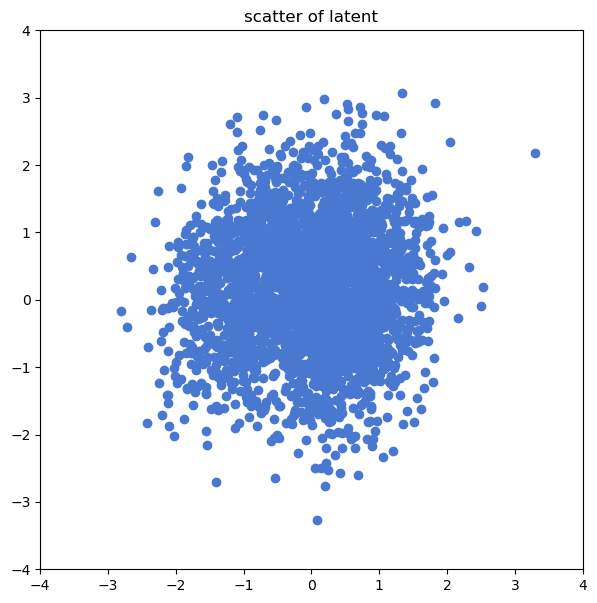

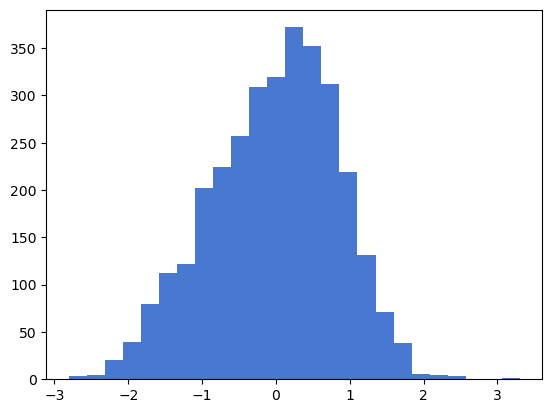

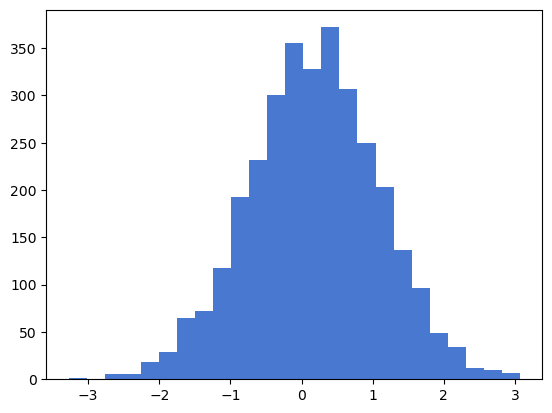

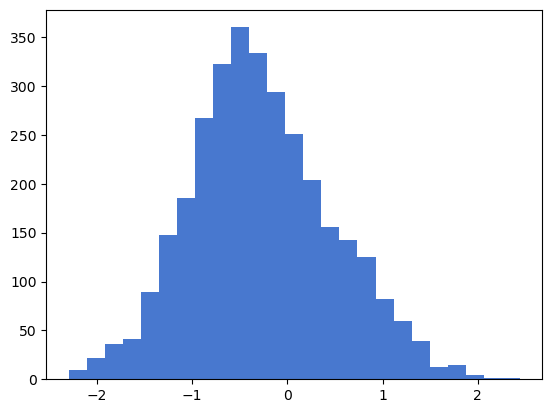

In [197]:
torch._dynamo.config.cache_size_limit = 64
n_coms = 50
model.eval()
latents = []
train_loader_iter = iter(train_loader)    
with torch.no_grad():
    for i in tqdm(range(n_coms)):
        y, x = next(train_loader_iter)
        y:torch.Tensor
        latent, log_det = model.forward(
            y.to(device), x.to(device)
        )
        latents.append(latent.detach())
latents = torch.cat(latents,dim=0)
latents = latents.cpu()
print(log_det.mean().cpu())
print(latents.shape)
print(f"Train Set: {latents.std(0)=}")
(print(f"{torch.cov(latents.T)=}"))
plt.figure(figsize=(7,7))
plt.scatter(latents[:, 0], latents[:, 1])
plt.title("scatter of latent")
plt.ylim((-4,4))
plt.xlim((-4,4))
plt.savefig("latent.png")
plt.show()
plt.hist(latents[:, 0],bins=25)
plt.show()
plt.hist(latents[:, 1],bins=25)
plt.show()
plt.hist(latents[:, 2],bins=25)
plt.show()

torch.Size([30, 90]) torch.Size([30, 3])
torch.Size([3840, 3])


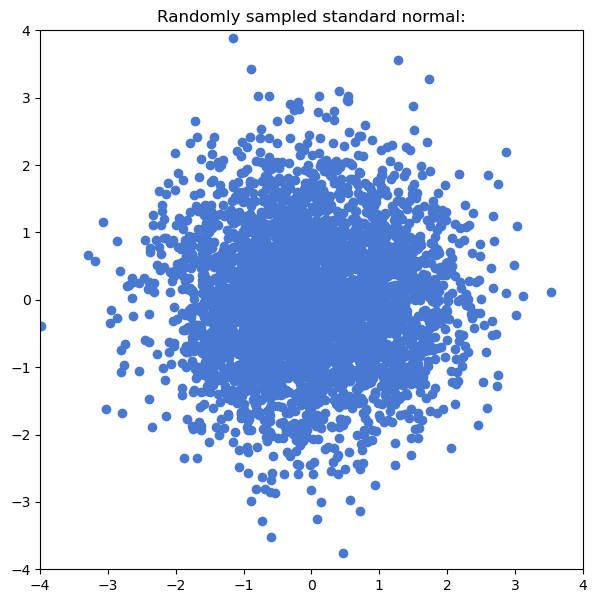

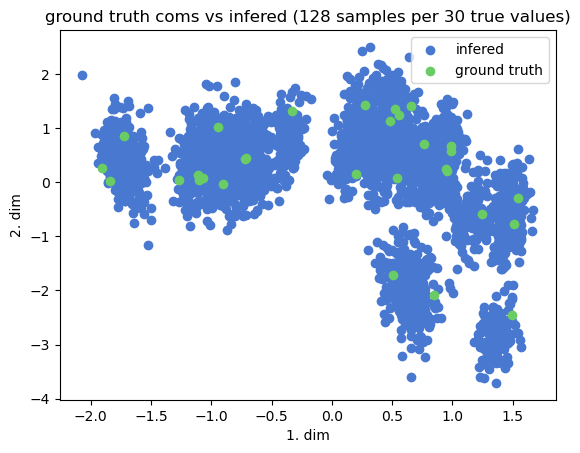

In [198]:
n_coms = 30
n_randoms_per_com = 128
model.eval() # disable dropout
model.to(device) # in case we use a model thats not on device, like fe if we just loaded it
normal = torch.normal(0, 1, (n_coms* n_randoms_per_com, 3))
train_xv_reverse = []
train_com_reverse = []
for y,x in train_loader_iter:
    train_xv_reverse.append(x)
    train_com_reverse.append(y)
    if sum([x.shape[0] for x in train_xv_reverse]) >= n_coms:
        break


train_xv_reverse = torch.cat(train_xv_reverse,dim=0)[:n_coms]
train_com_reverse = torch.cat(train_com_reverse,dim=0)[:n_coms]


print(train_xv_reverse.shape,train_com_reverse.shape)
infered_coms = model.reverse(normal.to(device), train_xv_reverse.flatten(1).to(device).repeat_interleave(n_randoms_per_com,dim=0))


print(infered_coms.shape)

infered_coms  = infered_coms.detach().cpu()


plt.figure(figsize=(7,7))
plt.scatter(normal[:,0],normal[:,1])
plt.title("Randomly sampled standard normal:")
plt.ylim((-4,4))
plt.xlim((-4,4))
plt.show()
plt.scatter(infered_coms[:, 0], infered_coms[:, 1])
plt.scatter(train_com_reverse[:,0],train_com_reverse[:,1])
plt.title(f"ground truth coms vs infered ({n_randoms_per_com} samples per {n_coms} true values)")
plt.legend(["infered","ground truth"])
plt.xlabel("1. dim")
plt.ylabel("2. dim")
plt.show()

In [199]:
#back,_ = model.forward(infered_coms.to(device),train_xv_reverse.flatten(1).to(device))
# back is only interesting to see if invertability is working
print(f"Train Set: {infered_coms.std(0)=}")
(print(f"{torch.cov(infered_coms.T)=}"))

Train Set: infered_coms.std(0)=tensor([0.9876, 0.9853, 1.0902])
torch.cov(infered_coms.T)=tensor([[ 0.9754, -0.3358,  0.6378],
        [-0.3358,  0.9708,  0.0877],
        [ 0.6378,  0.0877,  1.1885]])


In [200]:
def return_to_real(com:torch.Tensor,foot:torch.Tensor,stats):
    W = stats["W"]
    foot_mean = np.array(stats["foot_mean"], dtype=np.float32)
    foot_std = np.array(stats["foot_std"], dtype=np.float32)
    com_mean = np.array(stats["com_mean"], dtype=np.float32)
    com_std = np.array(stats["com_std"], dtype=np.float32)

    print(com_std.shape,foot_std.shape)
    com_out = com * com_std + com_mean
    foot_out = foot.reshape((-1,15,6)) * foot_std + foot_mean
    return com_out,foot_out


com_corr, foot_corr = return_to_real(infered_coms,train_xv_reverse,stats)
print(com_corr.shape,foot_corr.shape)

(3,) (1, 1, 6)
torch.Size([3840, 3]) torch.Size([30, 15, 6])


/tmp/ipykernel_23241/1005551991.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  com_out = com * com_std + com_mean
/tmp/ipykernel_23241/1005551991.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  foot_out = foot.reshape((-1,15,6)) * foot_std + foot_mean


In [201]:
# calculate random coms ground truths of other samples to show
#  that the posterior is better than prior
n_random_train_coms = n_randoms_per_com
rng = np.random.default_rng(324)
random_indices = rng.permutation(len(train_yv))[:n_random_train_coms]
print(f"{random_indices.shape=}")
random_truth_coms = train_yv[random_indices] * stats["com_std"] + stats["com_mean"]
print(f"{random_truth_coms.shape=}")


random_indices.shape=(128,)
random_truth_coms.shape=torch.Size([128, 3])


/tmp/ipykernel_23241/434375013.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  random_truth_coms = train_yv[random_indices] * stats["com_std"] + stats["com_mean"]


/tmp/ipykernel_23241/182834054.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  truth_com = train_com_reverse[i_th_example,:] * stats["com_std"] + stats["com_mean"]


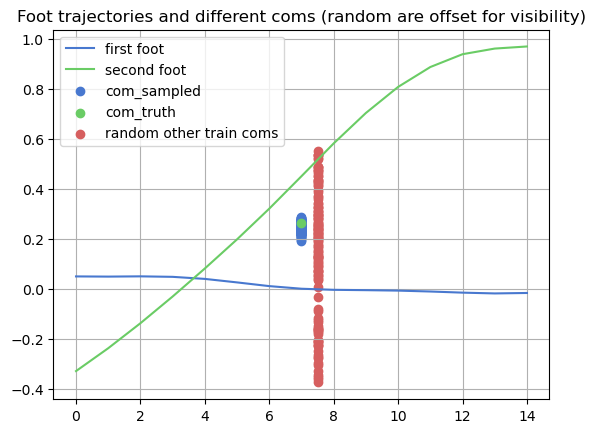

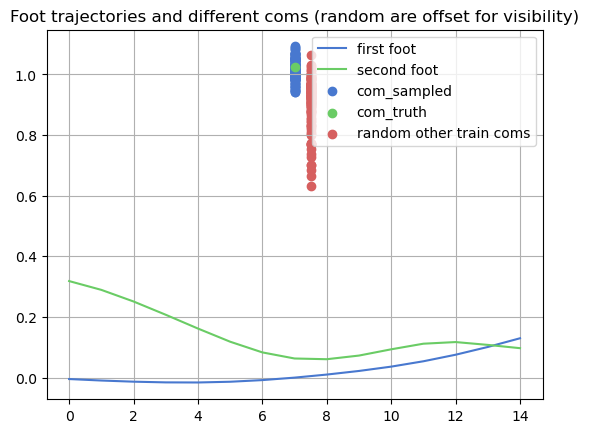

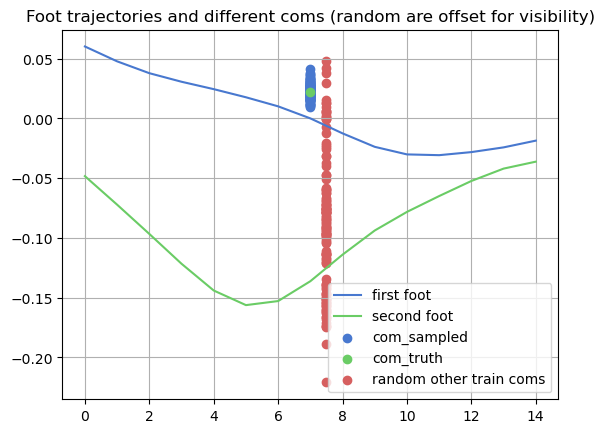

In [202]:
i_th_example= np.random.randint(0,n_coms)
test = foot_corr 

midpoint = torch.tensor([7]).repeat_interleave(n_randoms_per_com)
truth_com = train_com_reverse[i_th_example,:] * stats["com_std"] + stats["com_mean"]
plt.grid()
plt.plot(test[i_th_example, :, 0])
plt.plot(test[i_th_example, :, 3])
plt.scatter(midpoint, com_corr[i_th_example*n_randoms_per_com:(i_th_example+1)*n_randoms_per_com, 0])
plt.scatter([7],truth_com[0] )
plt.scatter([7.5]*n_random_train_coms,random_truth_coms[:,0])
plt.legend(["first foot", "second foot", "com_sampled","com_truth","random other train coms"])
plt.title("Foot trajectories and different coms (random are offset for visibility)")
plt.show()
plt.grid()
plt.plot(test[i_th_example, :, 1])
plt.plot(test[i_th_example, :, 4])
plt.scatter(midpoint, com_corr[i_th_example*n_randoms_per_com:(i_th_example+1)*n_randoms_per_com, 1])
plt.scatter([7],truth_com[1])
plt.scatter([7.5]*n_random_train_coms,random_truth_coms[:,1])
plt.legend(["first foot", "second foot", "com_sampled","com_truth","random other train coms"])
plt.title("Foot trajectories and different coms (random are offset for visibility)")
plt.show()
plt.grid()
plt.plot(test[i_th_example, :, 2])
plt.plot(test[i_th_example, :, 5])
plt.scatter(midpoint, com_corr[i_th_example*n_randoms_per_com:(i_th_example+1)*n_randoms_per_com, 2])
plt.scatter([7],truth_com[2])
plt.scatter([7.5]*n_random_train_coms,random_truth_coms[:,2])
plt.legend(["first foot", "second foot", "com_sampled","com_truth","random other train coms"])
plt.title("Foot trajectories and different coms (random are offset for visibility)")
plt.show()

foot_data__for_posterior.shape=torch.Size([2500, 90])
posterior_data.shape=torch.Size([2500, 3])
posterior_data_reshape.shape=torch.Size([2500, 3])
posterior_x.shape=torch.Size([2500])


/tmp/ipykernel_23241/1854210366.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  posterior_global_shift = posterior_data_reshape * stats["com_std"] + stats["com_mean"]


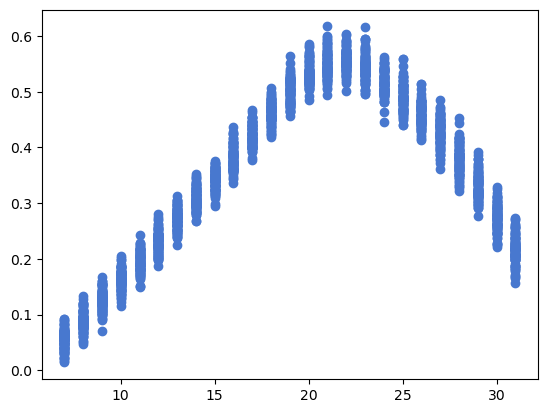

In [203]:
# now try to build the posterior trace

# we have 25 windows.
# lets sample n_sample_per_window := 100 points for this

n_sample_per_window = 100
foot_data__for_posterior = test_foot[:25,:,:].flatten(1).repeat_interleave(n_sample_per_window,dim=0)
print(f"{foot_data__for_posterior.shape=}")
normal = torch.randn((25 * n_sample_per_window,3),device=device)
posterior_data = model.reverse(normal,foot_data__for_posterior.to(device))

print(f"{posterior_data.shape=}")
posterior_data_reshape = posterior_data.detach().cpu()#.reshape(25,n_sample_per_window,3)
print(f"{posterior_data_reshape.shape=}")

posterior_global_shift = posterior_data_reshape * stats["com_std"] + stats["com_mean"]
posterior_x = (torch.arange(25) + 7).repeat_interleave(n_sample_per_window)
print(f"{posterior_x.shape=}")
_ = plt.scatter(posterior_x,posterior_global_shift[:,0])

test_foot.shape=torch.Size([500000, 15, 6])
first_part.shape=torch.Size([15, 6])
second_part.shape=torch.Size([14, 6])
entire_trajectory.shape=(39, 6)


/tmp/ipykernel_23241/1443910216.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected_test_foot = test_foot * stats["foot_std"] + stats["foot_mean"]
/tmp/ipykernel_23241/1443910216.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  corrected_test_com = test_com * stats["com_std"] + stats["com_mean"] # only use for plotting!!
/tmp/ipykernel_23241/1443910216.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  posterior_local_shift = posterior_global_shift.reshape(25,n_sample_per_window,3)+ entire_trajectory[7:32,None,:3]
/tmp/ipykernel_23241/1443910216.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.

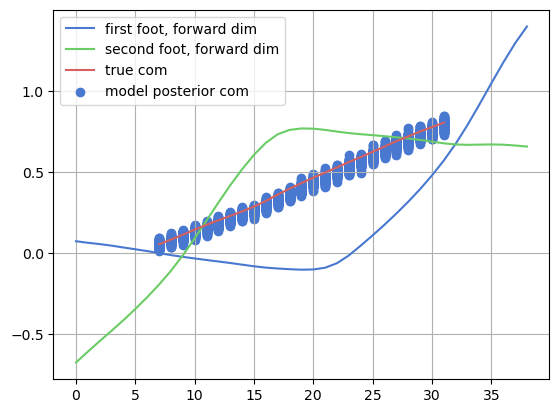

/tmp/ipykernel_23241/1443910216.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.arange(25)+7, corrected_test_com[0:25,1] + entire_trajectory[7:32,1] ,label="true com")


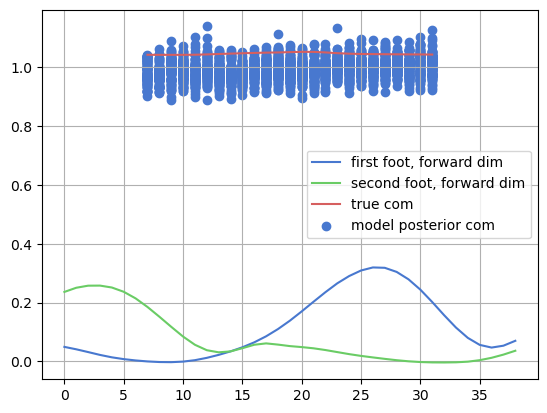

/tmp/ipykernel_23241/1443910216.py:51: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.arange(25)+7, corrected_test_com[0:25,2] + entire_trajectory[7:32,2] ,label="true com")


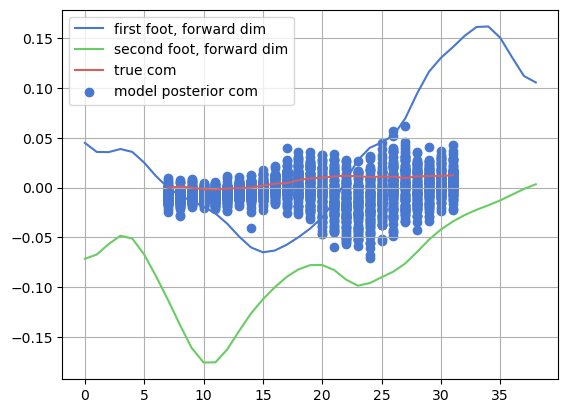

In [ ]:
print(f"{test_foot.shape=}")
# for i in range(25):
#     plt.plot(np.arange(15) + i, test_foot[i, :, 0], label=f"{i}")
# plt.title("uncorrected trajectories of windows of the same simulation")
# plt.show()


corrected_test_foot = test_foot * stats["foot_std"] + stats["foot_mean"]
corrected_test_com = test_com * stats["com_std"] + stats["com_mean"] # only use for plotting!!

first_part = corrected_test_foot[0, :, :]
second_part = (
    corrected_test_foot[14, :, :][1:]
    - corrected_test_foot[14, 0, :]
    + first_part[-1, :]
)
print(f"{first_part.shape=}")
print(f"{second_part.shape=}")
last_part = (
    corrected_test_foot[24, :, :][5:]
    - corrected_test_foot[24, 4, :]
    + second_part[-1, :]
)

entire_trajectory = np.concatenate(
    [
        first_part,
        second_part,
        last_part,
    ]
)
posterior_local_shift = posterior_global_shift.reshape(25,n_sample_per_window,3)+ entire_trajectory[7:32,None,:3]
print(f"{entire_trajectory.shape=}")
plt.plot(np.arange(39), entire_trajectory[:, 0],label="")
plt.plot(np.arange(39), entire_trajectory[:, 3],label="")
plt.plot(np.arange(25)+7, corrected_test_com[0:25,0] + entire_trajectory[7:32,0] ,label="true com")
plt.scatter(posterior_x,posterior_local_shift[:,:,0].flatten() )
plt.grid()
plt.legend(["first foot, forward dim","second foot, forward dim","true com","model posterior com"])
plt.show()
plt.plot(np.arange(39), entire_trajectory[:, 1],label="first foot, height dim")
plt.plot(np.arange(39), entire_trajectory[:, 4],label="second foot, height dim")
plt.plot(np.arange(25)+7, corrected_test_com[0:25,1] + entire_trajectory[7:32,1] ,label="true com")
plt.scatter(posterior_x,posterior_local_shift[:,:,1].flatten() )
plt.grid()
plt.legend(["first foot, forward dim","second foot, forward dim","true com","model posterior com"])
plt.show()
plt.plot(np.arange(39), entire_trajectory[:, 2],label="first foot, (is this vertical) dim")
plt.plot(np.arange(39), entire_trajectory[:, 5],label="second foot, (is this vertical) dim")
plt.plot(np.arange(25)+7, corrected_test_com[0:25,2] + entire_trajectory[7:32,2] ,label="true com")
plt.scatter(posterior_x,posterior_local_shift[:,:,2].flatten() )
plt.grid()
plt.legend(["first foot, forward dim","second foot, forward dim","true com","model posterior com"])
plt.show()

# plt.scatter(
#     np.arange(28, 39),
#     corrected_test_foot[24, :, foot_dim][4:]
#     - corrected_test_foot[24, 4, foot_dim]
#     + second_part[-1],
#     color="red",
# ) #debug

In [205]:
if input("save (type save to save)") == "save":
    print("saving")
    filename_model_params = "saved_model_test.model"
    filename_model_hyperparams = "saved_model_test.def"
    torch.save(model.state_dict(), filename_model_params)
    model_hyperparams_dict = {
        "input_size": model.realNVP.input_size,
        "condition_size": model.summary.input_size,
        "reduced_condition_size": model.realNVP.condition_size,
        "s_hidden": model.summary.encoder_layers[1].weight.shape[0],
        "s_layers": model.summary.layers,
        "r_hidden": model.realNVP.blocks[0].scale_net[0].weight.shape[0],
        "r_blocks": len(model.realNVP.blocks),
    }
    torch.save(model_hyperparams_dict, filename_model_hyperparams)
else:
    print("skipping saving")

skipping saving


In [206]:
filename_model_params = "saved_model_test.model"
filename_model_hyperparams = "saved_model_test.def"
init_dict = torch.load(filename_model_hyperparams)
print(init_dict)
loaded_dict = torch.load(filename_model_params)
model = RealNVPSummary(**init_dict)
model = torch.compile(model)
model: RealNVPSummary
model.load_state_dict(loaded_dict)
model.to(device)

{'input_size': 3, 'condition_size': 90, 'reduced_condition_size': 29, 's_hidden': 256, 's_layers': 5, 'r_hidden': 128, 'r_blocks': 30}


OptimizedModule(
  (_orig_mod): RealNVPSummary(
    (summary): RegressionNetwork(
      (encoder): Sequential(
        (0): Dropout(p=0.1, inplace=False)
        (1): Linear(in_features=90, out_features=256, bias=True)
        (2): ReLU()
        (3): Linear(in_features=256, out_features=256, bias=True)
        (4): ReLU()
        (5): Linear(in_features=256, out_features=256, bias=True)
        (6): ReLU()
        (7): Linear(in_features=256, out_features=256, bias=True)
        (8): ReLU()
        (9): Linear(in_features=256, out_features=256, bias=True)
        (10): ReLU()
        (11): Linear(in_features=256, out_features=256, bias=True)
        (12): ReLU()
        (13): Linear(in_features=256, out_features=29, bias=True)
      )
    )
    (realNVP): RealNVP(
      (blocks): ModuleList(
        (0): CouplingBlock(
          (scale_net): Sequential(
            (0): Linear(in_features=30, out_features=128, bias=True)
            (1): ReLU()
            (2): Linear(in_features=128,